## **Modelo preditivo de classificação de score de crédito**

### **Objetivo** 

#### classificar antecipadamente os clientes com scores de crédito: baixo, médio ou alto,

#### através de um modelo de machine learning capaz de cruzar as informações disponíveis dos indivíduos e avaliar os riscos de crédito,

#### auxiliando o time de negócios a trazer soluções aos clientes de acordo com sua classificação de risco.

### **Parte I**

#### - coleta e carregamento da base de dados,
#### - pré-processamento e limpeza,
#### - **Separação da base em treino e teste antes de qualquer transformação** e 
#### - Análise explorátoria dos dados.

### **Bibliotecas**

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### **Análise da estrutura da base de dados**

In [23]:
# lendo a base
base = pd.read_csv('../bases/base_bruta/credit_score.csv', delimiter=';')

#dicionário para traduzir as bases
dic_colunas = {
    'Age': 'idade',
    'Gender': 'genero',
    'Income': 'renda',
    'Education': 'nivel_educacional',
    'Marital Status': 'estado_civil',
    'Number of Children': 'qtd_filhos',
    'Home Ownership': 'propriedade', 
    'Credit Score': 'score_credito'
}

# renomeando as colunas
base = base.rename(columns=dic_colunas)

# Cópia para EDA
df = base.copy()

# visualizando a base
base.head()

,idade,genero,renda,nivel_educacional,estado_civil,qtd_filhos,propriedade,score_credito
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High


In [24]:
# analisando estrutura do dataset e nulos
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   idade              130 non-null    float64
 1   genero             164 non-null    object 
 2   renda              164 non-null    object 
 3   nivel_educacional  164 non-null    object 
 4   estado_civil       164 non-null    object 
 5   qtd_filhos         164 non-null    int64  
 6   propriedade        164 non-null    object 
 7   score_credito      164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB


#### Analisando a estrutura do dataframe, há valores nulos na coluna `idade` que serão tratados, além de ser necessário corrigir a tipagem dos dados para a etapa de modelagem

## **Separação da base em treino e teste**

In [25]:
# base x: todas as variáveis - target
X = base.drop('score_credito', axis=1)

# codificando score_credito: baixo (0), medio (1), alto (2)
score_credito = {
    'Low': 0,
    'Average': 1,
    'High': 2     
}

base['score_credito'] = base['score_credito'].map(score_credito)

# base y com a variável target
y = base['score_credito']

# split da base
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### **Análise de tratamento de nulos e duplicatas**

In [26]:
# qtd de nulos em cada variável
X_train.isnull().sum()

idade                28
genero                0
renda                 0
nivel_educacional     0
estado_civil          0
qtd_filhos            0
propriedade           0
dtype: int64

In [27]:
percentual = ((X_train['idade'].isnull().sum() / X_train.shape[0]) * 100).round(2)
print(f'a coluna idade possui {percentual}% de nulos')

a coluna idade possui 21.37% de nulos


#### Os valores nulos da coluna `idade` serão substituidos pela mediana do histórico da base (base de treino), pois é uma métrica mais robusta que a média e menos sensível à outliers.

In [28]:
# substituindo nulos por mediana
idade_mediana = X_train['idade'].median()

X_train['idade'] = X_train['idade'].fillna(idade_mediana)
X_test['idade'] = X_test['idade'].fillna(idade_mediana)

In [29]:
print(f'qtd de registros duplicados: {X_train.duplicated().sum()}')

qtd de registros duplicados: 33


In [30]:
X_train[X_train.duplicated(keep=False)].sort_values(by='idade', ascending=False).head()

,idade,genero,renda,nivel_educacional,estado_civil,qtd_filhos,propriedade
140,50.0,Male,"155.000,00",Master's Degree,Married,0,Owned
34,50.0,Male,"155.000,00",Master's Degree,Married,0,Owned
121,49.0,Female,"77.500,00",Doctorate,Married,1,Owned
163,49.0,Female,"77.500,00",Doctorate,Married,1,Owned
57,49.0,Female,"77.500,00",Doctorate,Married,1,Owned


#### Optou-se por não exluir os valores duplicados na base, pelo impacto de viés que poderia causar em uma base pequena e por não parecer ser erro de coleta e sim regra de negócio, sendo compreensível a igualdade de renda entre os indivíduos dependendo de como foram coletadas essas rendas.

### **Validação**

In [31]:
print(f'qtde de nulos pós tratamento: {X_train.isnull().sum().sum()}\n')

qtde de nulos pós tratamento: 0



## **Análise Exploratória de Dados** 

### Análise da distribuição da coluna alvo

score_credito
High       69.0
Average    22.0
Low         9.0
Name: proportion, dtype: float64

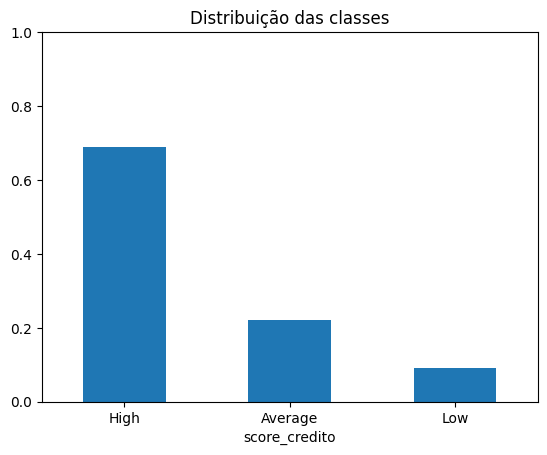

In [32]:
# tabela percentual
percentual = df['score_credito'].value_counts(normalize=True)
display(percentual.round(2).mul(100))

# visual
df['score_credito'].value_counts(normalize=True).plot(kind='bar')

plt.title('Distribuição das classes')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

#### na base, somente 9% possuem score baixo de crédito,
#### enquanto 22% possuem score médio e 69% possuem score alto de crédito.
#### serão usadas possivelmente técnicas de balanceamento para mitigar alguma dificuldade que o modelo tenha em prever a classe minoriária.

## **Codificando as variáveis categóricas em numéricas**

In [33]:
# codificando genero: feminino (0), masculino (1)
genero = {
    'Female': 0,
    'Male': 1
}

# codificando estado civil: solteiro (0), casado (1)
estado_civil = {
    'Single': 0,
    'Married': 1
}

# codificando propriedade: alugada (0), própria (1)
propriedade= {
'Rented': '0',
'Owned': '1'
}

# codificando score_credito: baixo (0), medio (1), alto (2)
score_credito = {
    'Low': 0,
    'Average': 1,
    'High': 2     
}

df['genero']        = df['genero'].map(genero)
df['estado_civil']  = df['estado_civil'].map(estado_civil)
df['propriedade']   = df['propriedade'].map(propriedade)
df['score_credito'] = df['score_credito'].map(score_credito)

# transformando renda em tipo flutuante
df['renda'] = df['renda'].str.replace('.', '').str.replace(',', '.').astype(float)

# dummificando nível educacional pois não é uma variável ordinal
df = pd.get_dummies(df, columns=['nivel_educacional'], drop_first=False, dtype=int)

## **Análise da correlação linear**

In [34]:
# correlação linear
corr = df.corr()

display(corr['score_credito'].sort_values(ascending=False).reset_index().head())

,index,score_credito
0,score_credito,1.000000
1,propriedade,0.854970
2,renda,0.744407
3,idade,0.656199
4,estado_civil,0.619854


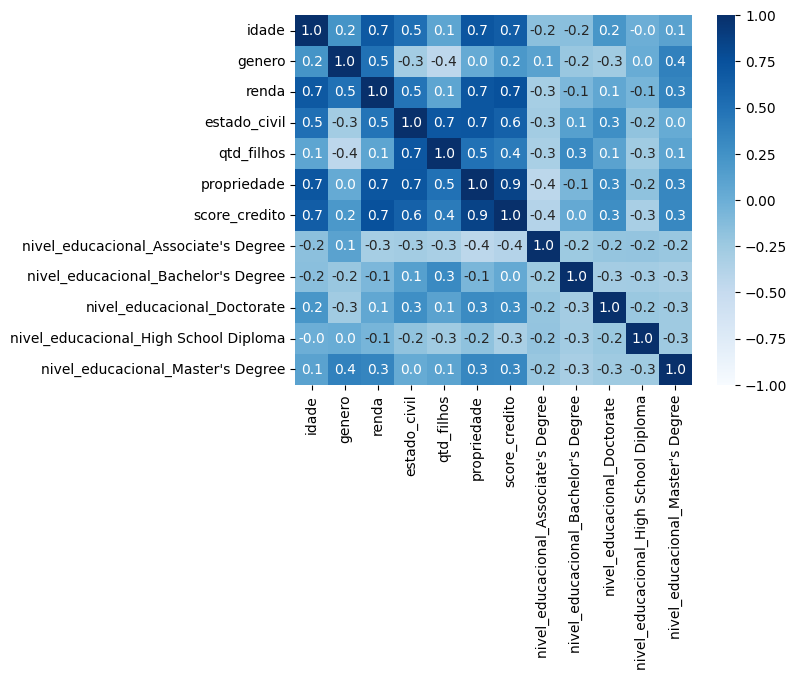

In [35]:
sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    vmin=-1,
    vmax=1,
    fmt='.1f'
)

plt.show()

#### inicialmente, pode-se notar algumas variáveis fortemente correlacionadas com o target, que possam ajudar a entender a variabilidade do variável alvo:
- `propriedade: 85%` que sugere que quando o cliente possui propriedade própria (patrimônio), seu score de crédito é alto,
- `renda: 74%` que indica que conforme maior a renda, maior o score de crédito,
- `idade: 65%` também sugere que pessoas mais velhas, possuem mais solidez financeira e score de crédito maior.

## **Análise bivariada:**

### **Propriedade vs Score de crédito**

score_credito,propriedade,0,1,2
0,0,15,34,4
1,1,0,2,109


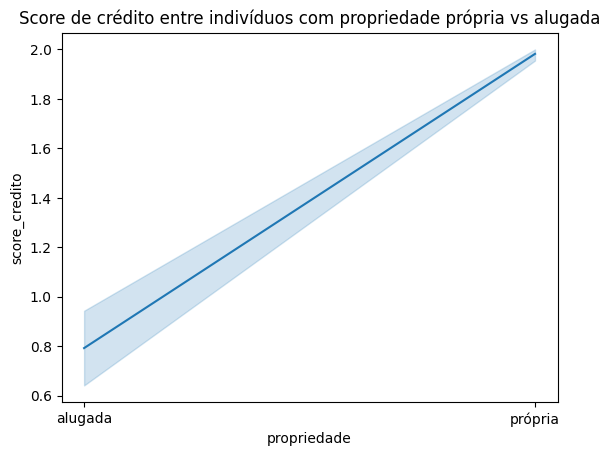

In [36]:
# tabela correlacionando as duas variáveis
score= df.pivot_table(
    index='propriedade',
    columns='score_credito',
    aggfunc='size',
    fill_value=0  # Coloca 0 onde não houver nenhum registro no cruzamento
).reset_index()

display(score)

# visual
ax = sns.lineplot(
    data=df,
    x='propriedade',
    y='score_credito',
)
plt.title('Score de crédito entre indivíduos com propriedade própria vs alugada')
plt.xticks([0, 1], ['alugada', 'própria'])


plt.show()

#### cruzando os dados, é possível notar que de 111 clientes que possuem casa própria, 109 possuem score alto e nenhum dele possui score baixo, indicando que essa variável é uma forte preditora.

### **Propriedade vs estado civil**

estado_civil,0,1
propriedade,,
0,52,1
1,25,86


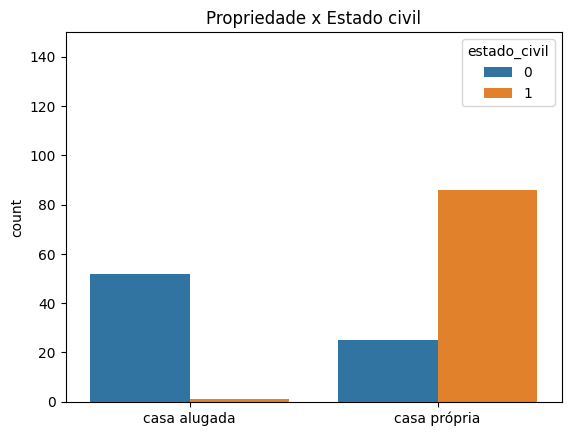

In [37]:
# tabela correlacionando as duas variáveis
est_civil=pd.pivot_table(
    df,
    index='propriedade',
    columns='estado_civil',
    aggfunc='size'
)

display(est_civil)

# visual
sns.countplot(
    df,
    x='propriedade',
    hue='estado_civil'
)

plt.title('Propriedade x Estado civil')
plt.xticks([0,1], ['casa alugada', 'casa própria'])
plt.ylim(0,150)
plt.xlabel('')
plt.show()

#### analisando a moradia entre casados e solteiros, de 53 que moram de aluguel, 52 são solteiros, revelando um comportamento na base de dados.

### **Renda vs estado civil**

estado_civil,score_credito,0,1
0,0,32000.00,0.00
1,1,55147.06,61500.00
2,2,101696.43,98964.71


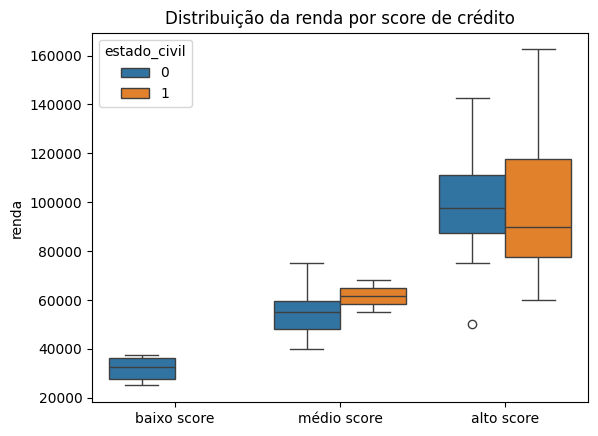

In [38]:
# tabela dinâmica
renda = pd.pivot_table(
    df,
    index='score_credito',
    columns='estado_civil',
    values='renda',
    aggfunc='mean',
    fill_value=0
).reset_index()

display(renda.round(2))

# visual
sns.boxplot(
    df,
    x='score_credito',
    y='renda',
    hue='estado_civil'
)

plt.title('Distribuição da renda por score de crédito')
plt.xticks([0, 1 , 2], ['baixo score', 'médio score', 'alto score'])
plt.xlabel('')
#plt.legend(title='estado civil', labels=['solteiro', 'casado'])

plt.show()

#### nessa base, 100% dos solteiros que possuem faixa de renda baixa possuem baixo score, revelando mais um comportamento do risco de crédito para pessoas com esse perfil,
#### enquanto faixas de rendas maiores, podem ter score médio ou alto tanto solteiros quanto casados.

### **score de crédito vs estado civil**

estado_civil,score_credito,0,1
0,0,15,0
1,1,34,2
2,2,28,85


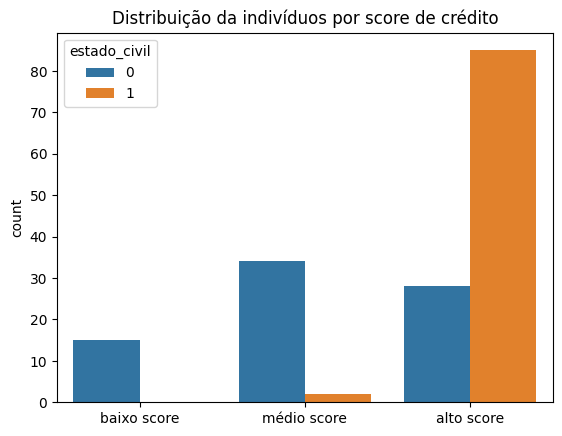

In [39]:
# tabela dinâmica
qtd = pd.pivot_table(
    df,
    index='score_credito',
    columns='estado_civil',
    #values='renda',
    aggfunc='size',
    fill_value=0
).reset_index()

display(qtd.round(2))

# visual
sns.countplot(
    df,
    x='score_credito',
    hue='estado_civil'
)

plt.title('Distribuição da indivíduos por score de crédito')
plt.xticks([0, 1 , 2], ['baixo score', 'médio score', 'alto score'])
plt.xlabel('')
#plt.legend(title='estado civil', labels=['solteiro', 'casado'])

plt.show()

#### de 51 clientes que possuem score baixo ou médio, 49 são solteiros. Não há casados com baixo score de crédito,
#### de 87 clientes casados, 85 possuem score de crédito alto. 
#### Isso indica que estado civil também será importante para o modelo.

### **Idade vs score de crédito**

,score_credito,idade média
0,0,28.0
1,1,29.0
2,2,42.0


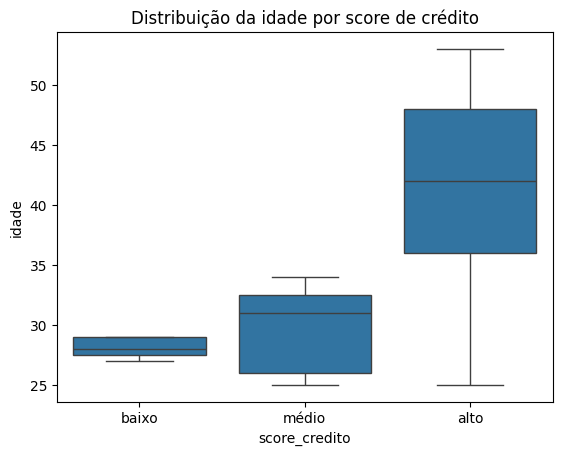

In [40]:
# tabela dinâmica
idade = df.groupby('score_credito')['idade'].mean().reset_index()
idade.columns=(['score_credito', 'idade média'])

display(idade.round(0))

# visual
ax = sns.boxplot(
    df,
    x='score_credito',
    y='idade'
)

plt.title('Distribuição da idade por score de crédito')
plt.xticks([0,1,2], ['baixo', 'médio', 'alto'])
plt.show()


#### A distribuição da idade de pessoas com score alto se concentra em idades elevadas, com media de 42 anos, enquanto a média de idade de pessoas com score baixo ou médio é de 28 e 29 anos, respectivamente.

## **Conclusões iniciais**

#### - Foi realizada a separação da base em treino e teste para isolar os dados de teste para uma melhor avaliação realista do comportamento do modelo em dados novos.
#### - depois foi realizada a limpeza da base, tratamento de valores nulos e permanência de duplicatas para evitar impacto de excluir
muita quantidade de linha em base pequena, além de não haver indícios de erro de coleta e sim regra de negócio.
#### - na exploração dos dados, percebeu-se que a base possui fortes variáveis que podem ajudar o modelo a explicar a variabilidade do score de crédito entre os clientes, com destaque para as variáveis `propriedade`, `estado_civil` e `renda`, que devem sofrer transformações na etapa de engenharia de atributos para munir ainda mais o modelo de informações.

## **Pré-modelagem**

### **Transformações de variáveis categóricas em numéricas**

In [41]:
# transformando idade em inteiro
X_train['idade'] = X_train['idade'].astype(int)
X_test['idade'] = X_test['idade'].astype(int)

# codificando genero: feminino (0), masculino (1)
genero = {
    'Female': 0,
    'Male': 1
}

# codificando estado civil: solteiro (0), casado (1)
estado_civil = {
    'Single': 0,
    'Married': 1
}

# codificando propriedade: alugada (0), própria (1)
propriedade= {
'Rented': '0',
'Owned': '1'
}

# codificando score_credito: baixo (0), medio (1), alto (2)
score_credito = {
    'Low': 0,
    'Average': 1,
    'High': 2     
}

X_train['genero']        = X_train['genero'].map(genero)
X_test['genero']         = X_test['genero'].map(genero)

X_train['estado_civil']  = X_train['estado_civil'].map(estado_civil)
X_test['estado_civil']   = X_test['estado_civil'].map(estado_civil)

X_train['propriedade']   = X_train['propriedade'].map(propriedade).astype(int)
X_test['propriedade']    = X_test['propriedade'].map(propriedade).astype(int)

# transformando renda em tipo flutuante
X_train['renda'] = X_train['renda'].str.replace('.', '').str.replace(',', '.').astype(float)
X_test['renda'] = X_test['renda'].str.replace('.', '').str.replace(',', '.').astype(float)

X_train = pd.get_dummies(X_train, columns=['nivel_educacional'], drop_first=False, dtype=int)
X_test = pd.get_dummies(X_test, columns=['nivel_educacional'], drop_first=False, dtype=int)

# alinhando as estruturas dos dataframes
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Validação
print(f'base de treino final: {X_train.shape[0]} linhas | {X_train.shape[1]} colunas')
print(f'base de teste final: {X_test.shape[0]} linhas | {X_test.shape[1]} colunas')

base de treino final: 131 linhas | 11 colunas
base de teste final: 33 linhas | 11 colunas


In [42]:
# Salvando para modelagem
import joblib
joblib.dump((X_train, X_test, y_train, y_test), '../bases/bases_modelagem/dados_modelagem.pkl')
print("\n💾 Salvo em: bases/bases_modelagem/dados_modelagem.pkl")


💾 Salvo em: bases/bases_modelagem/dados_modelagem.pkl
